# Deep Learning Project – Fashion MNIST

## Fokusområde: Input och Preprocessing

Syftet med detta projekt är att undersöka hur preprocessing påverkar en deep learning-modell för bildklassificering.

Vi använder Fashion MNIST-datasetet som innehåller bilder av olika klädesplagg.

Projektet fokuserar på:

- att förstå datan
- att förbereda input-data
- att analysera hur preprocessing påverkar modellens prestanda

In [158]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist


# Ladda in datasetet

Fashion MNIST finns direkt inbyggt i Keras och kan laddas automatiskt.

Datasetet innehåller:

- 60 000 träningsbilder
- 10 000 testbilder
- 10 olika klasser
- gråskalebilder med storlek 28x28 pixlar

In [159]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Undersöka datasetets struktur

Vi börjar med att undersöka:

- hur många bilder som finns
- bildstorlek
- hur labels ser ut

In [160]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


# Klassnamn

Fashion MNIST innehåller 10 olika kategorier av kläder och accessoarer.

In [161]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Visualisering av bilder

För att förstå datan bättre visualiserar vi några exempelbilder från datasetet.

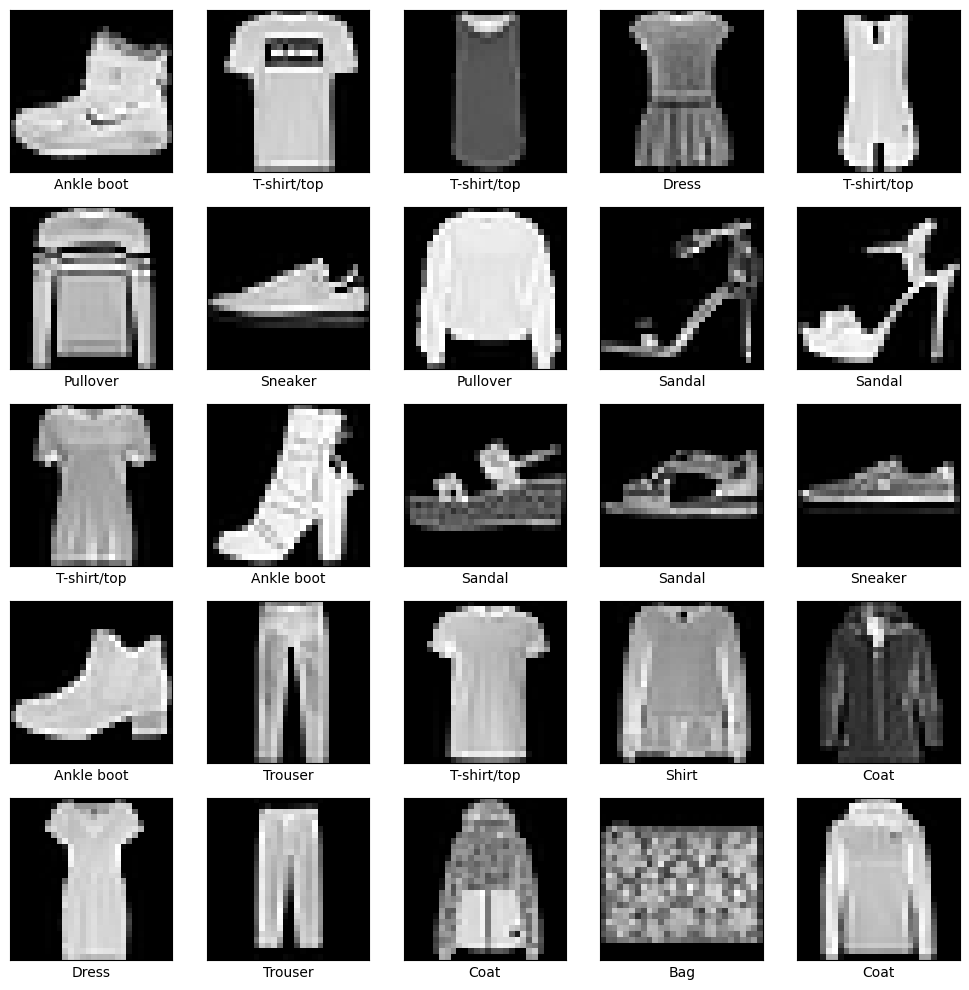

In [162]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_train[i], cmap='gray')
    plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()

# Analys av klassfördelning

Det är viktigt att kontrollera om datasetet är balanserat.

Om vissa klasser innehåller betydligt fler bilder än andra kan modellen bli biased.

In [163]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


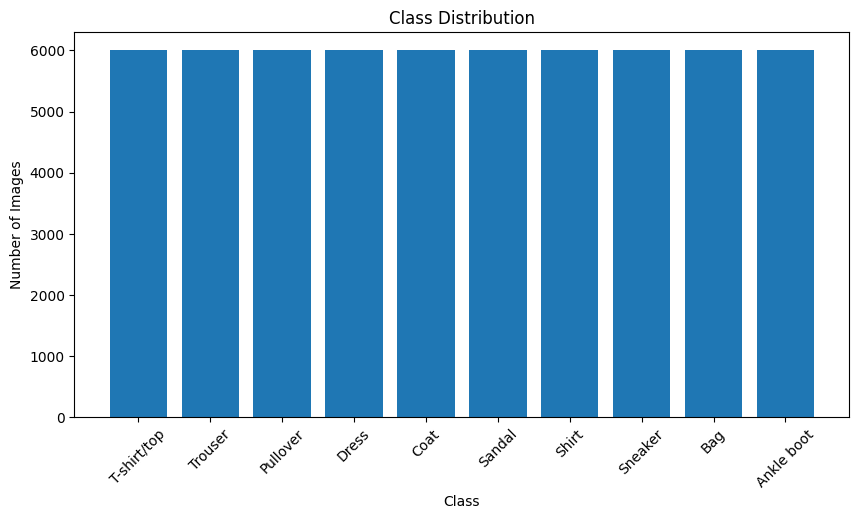

In [164]:
plt.figure(figsize=(10,5))

plt.bar(range(len(unique)), counts)

plt.xticks(range(len(unique)), class_names, rotation=45)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Analys av datasetet

Efter analysen kan vi se att:

- datasetet innehåller 10 klasser
- bilderna är gråskalebilder
- alla bilder har storleken 28x28
- datasetet är relativt balanserat

Detta är positivt eftersom balanserad data minskar risken för bias i modellen.

# Preprocessing av data

Innan datan används i en neural nätverksmodell behöver den preprocessas.

Preprocessing hjälper modellen att:

- träna stabilare
- lära sig snabbare
- förbättra prestanda

# Normalisering

Pixelvärden i bilderna ligger mellan 0 och 255.

Neurala nätverk fungerar bättre när värden skalas mellan 0 och 1.

Därför normaliserar vi bilderna genom att dividera med 255.

# Fokusområde - Input och preprocessing

Det här området handlar om hur datan förbereds innan den används i modellen.  
Ni kan till exempel undersöka:  
normalisering av pixelvärden  
hur datan formas (reshaping)   
skillnaden mellan olika sätt att mata in data i modellen  
Målet är att förstå hur datans format och kvalitet påverkar modellens inlärning.  

Jämförelser:
1. Normaliserad vs onormaliserad data i dense-model
2. Normaliserad vs onormaliserad data i cnn-model
3. Reshape vs inte reshaped data i cnn-model (båda är nomaliserade)
4. Dense vs CNN: skillnaden mellan flattenad pixeldata och spatial bildrepresentation (cnn är reshaped och dense är nomaliserad)

# Modeller

In [165]:
def create_dense_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [166]:
def create_cnn_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 1. Normaliserad vs onormaliserad data i dense-model

In [177]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_train.astype('float32') / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())
print("Min pixel value normalised:", x_train_norm.min())
print("Max pixel value normalised:", x_train_norm.max())

model_dense = create_dense_model()
model_dense_norm = create_dense_model()

history_model_dense = model_dense.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_dense_norm = model_dense_norm.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

Min pixel value: 0
Max pixel value: 255
Min pixel value normalised: 0.0
Max pixel value normalised: 1.0
Epoch 1/10


c:\Users\axelw\Documents\Deep learning\gruppuppgift\.venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6644 - loss: 3.3457 - val_accuracy: 0.6956 - val_loss: 0.8701
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7285 - loss: 0.7191 - val_accuracy: 0.7248 - val_loss: 0.7031
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7569 - loss: 0.6392 - val_accuracy: 0.7437 - val_loss: 0.6706
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7879 - loss: 0.5846 - val_accuracy: 0.8097 - val_loss: 0.5543
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8092 - loss: 0.5417 - val_accuracy: 0.8112 - val_loss: 0.5394
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8182 - loss: 0.5296 - val_accuracy: 0.7999 - val_loss: 0.5653
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8267 - loss: 0.4915 - val_accuracy: 0.7733 - val_loss: 0.6440
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8281 - loss: 0.4913 - val_accurac

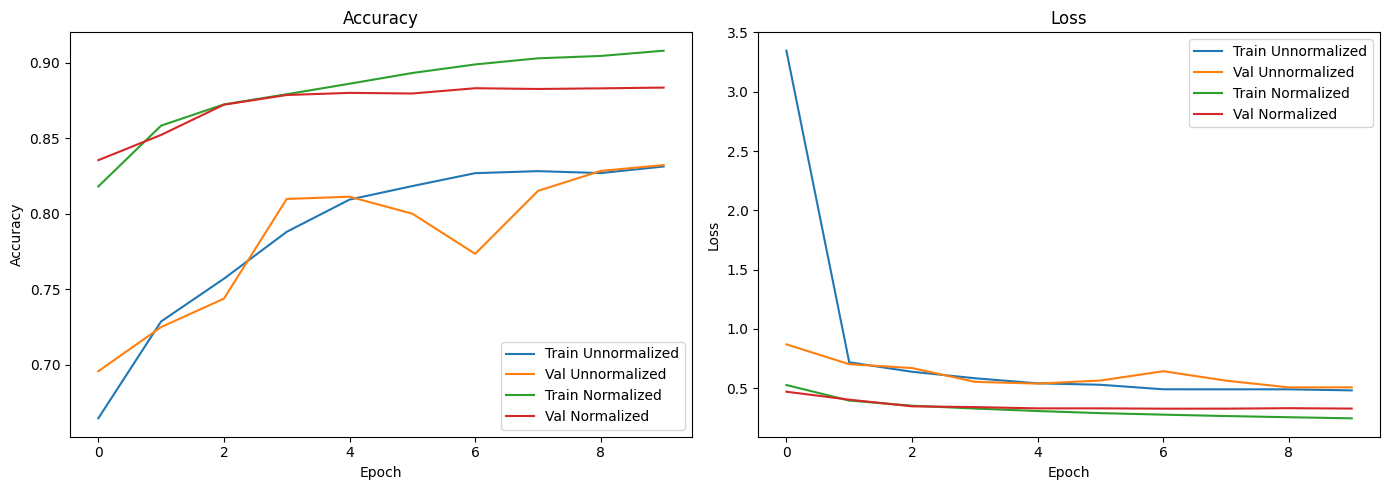

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_dense.history['accuracy'], label='Train Unnormalized')
axes[0].plot(history_model_dense.history['val_accuracy'], label='Val Unnormalized')

axes[0].plot(history_model_dense_norm.history['accuracy'], label='Train Normalized')
axes[0].plot(history_model_dense_norm.history['val_accuracy'], label='Val Normalized')

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_dense.history['loss'], label='Train Unnormalized')
axes[1].plot(history_model_dense.history['val_loss'], label='Val Unnormalized')

axes[1].plot(history_model_dense_norm.history['loss'], label='Train Normalized')
axes[1].plot(history_model_dense_norm.history['val_loss'], label='Val Normalized')

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Normaliserad vs onormaliserad data i cnn-model

In [ ]:
model_cnn = create_cnn_model()
model_cnn_norm = create_cnn_model()

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_train_cnn_norm = x_train_norm.reshape(-1, 28, 28, 1)

history_model_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_cnn_norm = model_cnn_norm.fit(
    x_train_cnn_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8487 - loss: 0.4815 - val_accuracy: 0.8845 - val_loss: 0.3115
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8924 - loss: 0.2938 - val_accuracy: 0.8920 - val_loss: 0.2976
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9048 - loss: 0.2568 - val_accuracy: 0.8951 - val_loss: 0.2886
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9135 - loss: 0.2321 - val_accuracy: 0.8959 - val_loss: 0.2905
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9209 - loss: 0.2125 - val_accuracy: 0.9058 - val_loss: 0.2656
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9288 - loss: 0.1917 - val_accuracy: 0.9036 - val_loss: 0.2870
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9341 - loss: 0.1770 - val_accuracy: 0.9017 - val_loss: 0.2918
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9395 - loss: 0.1618 - 

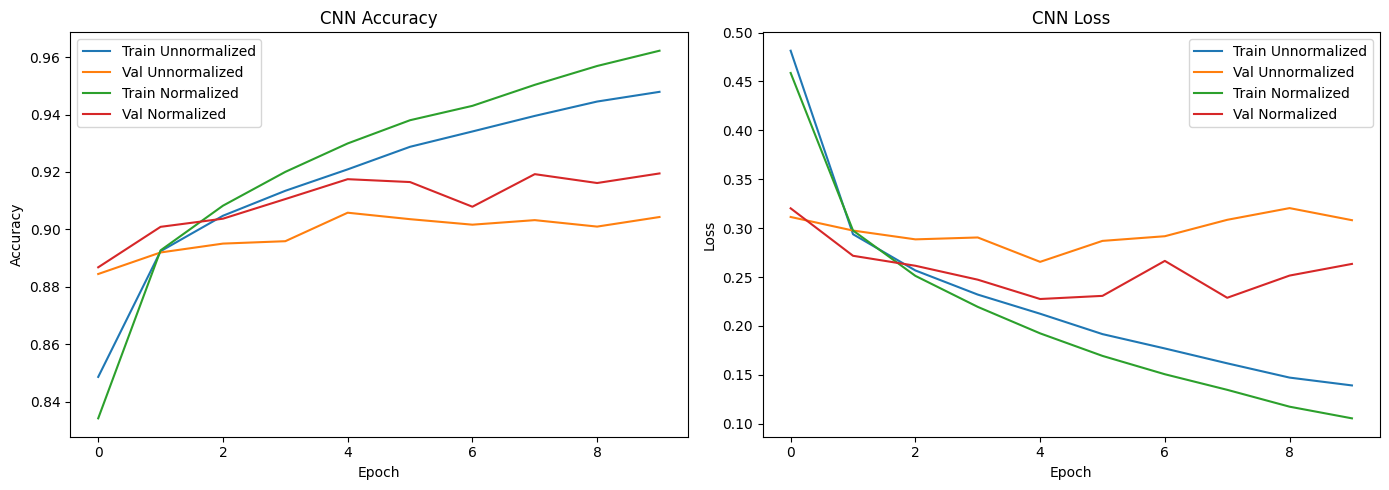

In [176]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_cnn.history['accuracy'], label='Train Unnormalized')
axes[0].plot(history_model_cnn.history['val_accuracy'], label='Val Unnormalized')

axes[0].plot(history_model_cnn_norm.history['accuracy'], label='Train Normalized')
axes[0].plot(history_model_cnn_norm.history['val_accuracy'], label='Val Normalized')

axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_cnn.history['loss'], label='Train Unnormalized')
axes[1].plot(history_model_cnn.history['val_loss'], label='Val Unnormalized')

axes[1].plot(history_model_cnn_norm.history['loss'], label='Train Normalized')
axes[1].plot(history_model_cnn_norm.history['val_loss'], label='Val Normalized')

axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Reshape vs inte reshaped data i cnn-model (båda är nomaliserade)

In [180]:
model_cnn_norm = create_cnn_model()
model_cnn_norm_reshape = create_cnn_model()

x_train_cnn_norm = x_train_norm
x_train_cnn_norm_reshape = x_train_norm.reshape(-1, 28, 28, 1)

history_model_cnn_norm = model_cnn_norm.fit(
    x_train_cnn_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_model_cnn_norm_reshape = model_cnn_norm_reshape.fit(
    x_train_cnn_norm_reshape,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8386 - loss: 0.4506 - val_accuracy: 0.8778 - val_loss: 0.3385
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8944 - loss: 0.2924 - val_accuracy: 0.8993 - val_loss: 0.2757
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9116 - loss: 0.2440 - val_accuracy: 0.9049 - val_loss: 0.2624
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9214 - loss: 0.2138 - val_accuracy: 0.9107 - val_loss: 0.2429
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9321 - loss: 0.1867 - val_accuracy: 0.9130 - val_loss: 0.2436
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9379 - loss: 0.1666 - val_accuracy: 0.9164 - val_loss: 0.2313
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9485 - loss: 0.1427 - val_accuracy: 0.9186 - val_loss: 0.2473
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9529 - loss: 0.1260 - 

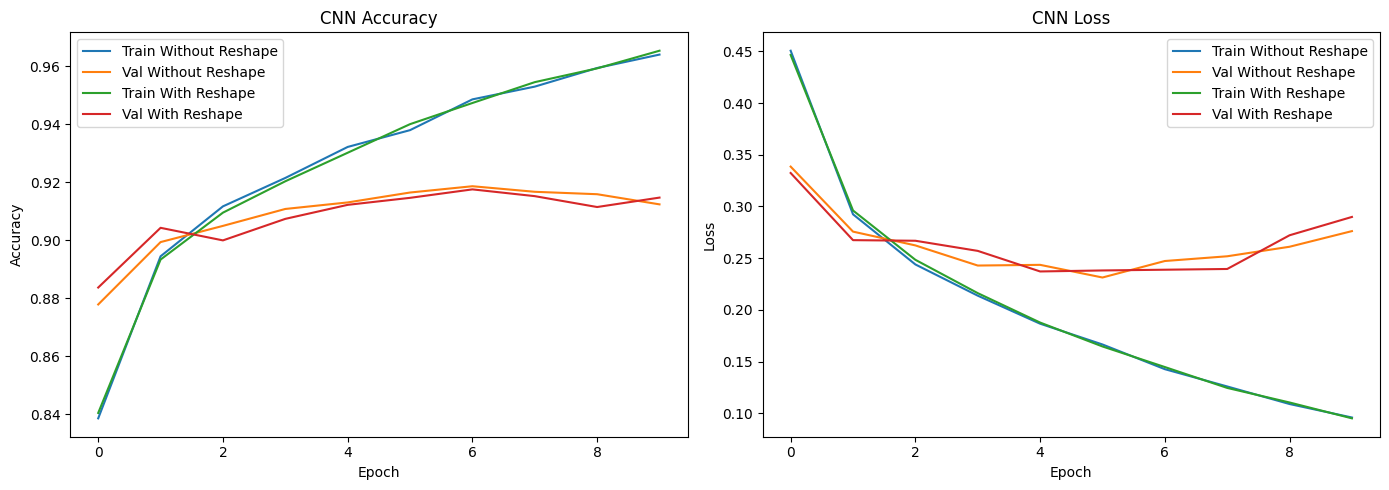

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_cnn_norm.history['accuracy'], label='Train Without Reshape')
axes[0].plot(history_model_cnn_norm.history['val_accuracy'], label='Val Without Reshape')

axes[0].plot(history_model_cnn_norm_reshape.history['accuracy'], label='Train With Reshape')
axes[0].plot(history_model_cnn_norm_reshape.history['val_accuracy'], label='Val With Reshape')

axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_cnn_norm.history['loss'], label='Train Without Reshape')
axes[1].plot(history_model_cnn_norm.history['val_loss'], label='Val Without Reshape')

axes[1].plot(history_model_cnn_norm_reshape.history['loss'], label='Train With Reshape')
axes[1].plot(history_model_cnn_norm_reshape.history['val_loss'], label='Val With Reshape')

axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Dense vs CNN: skillnaden mellan flattenad pixeldata och spatial bildrepresentation (cnn är reshaped och dense är nomaliserad)

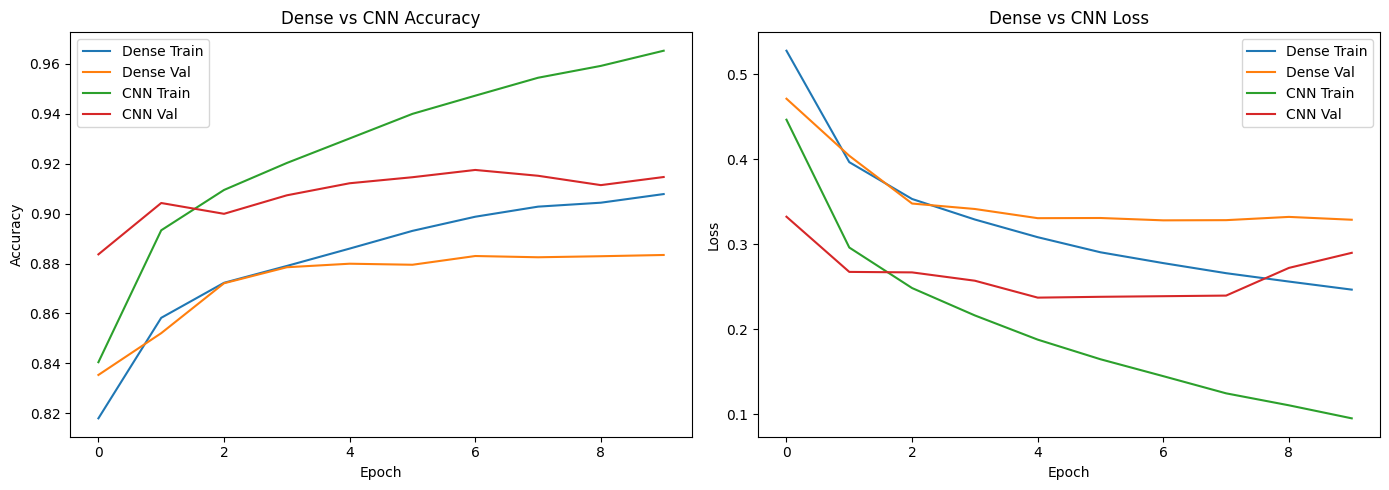

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------------- ACCURACY ----------------
axes[0].plot(history_model_dense_norm.history['accuracy'], label='Dense Train')
axes[0].plot(history_model_dense_norm.history['val_accuracy'], label='Dense Val')

axes[0].plot(history_model_cnn_norm_reshape.history['accuracy'], label='CNN Train')
axes[0].plot(history_model_cnn_norm_reshape.history['val_accuracy'], label='CNN Val')

axes[0].set_title('Dense vs CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ---------------- LOSS ----------------
axes[1].plot(history_model_dense_norm.history['loss'], label='Dense Train')
axes[1].plot(history_model_dense_norm.history['val_loss'], label='Dense Val')

axes[1].plot(history_model_cnn_norm_reshape.history['loss'], label='CNN Train')
axes[1].plot(history_model_cnn_norm_reshape.history['val_loss'], label='CNN Val')

axes[1].set_title('Dense vs CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Slutsats

I denna del av projektet har vi:

- undersökt datasetet
- analyserat klassfördelning
- normaliserat bilderna
- förberett datan för CNN-modellen

Preprocessing är viktigt eftersom kvaliteten på input-data påverkar modellens resultat.

## Träna modellen

I denna del tränas CNN-modellen på träningsdatan. Vi använder `x_train` och `y_train` som träningsdata.

Vi använder också `validation_split=0.2`, vilket betyder att 20 procent av träningsdatan används som valideringsdata. Det gör att vi kan följa hur modellen presterar på data som den inte tränas direkt på.

Modellen tränas i 10 epoker. En epok betyder att modellen går igenom hela träningsdatan en gång. Genom att följa `accuracy`, `loss`, `val_accuracy` och `val_loss` kan vi se om modellen förbättras över tid.

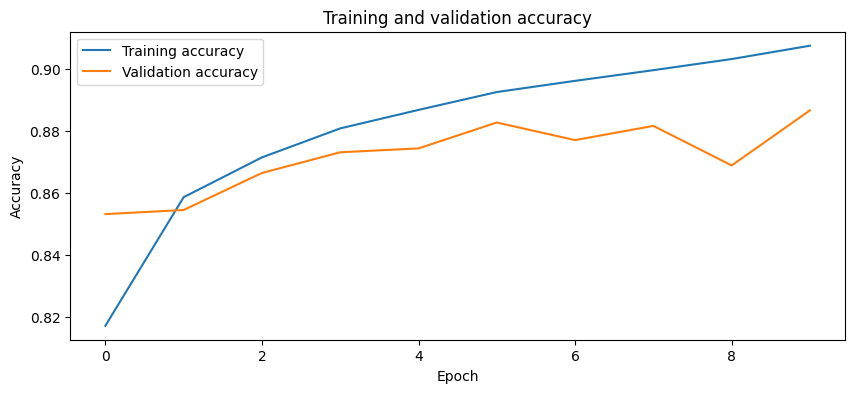

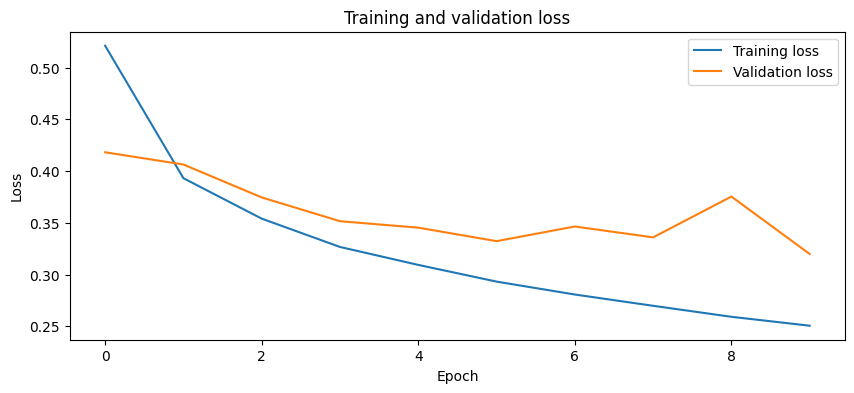

In [172]:
# Visualisera accuracy och loss

plt.figure(figsize=(10, 4))

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')

plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Analys av träningen

Under träningen följer vi hur modellens accuracy och loss förändras över tid.

I vårt resultat ökade training accuracy till ungefär 95 %, medan validation accuracy stabiliserades runt 92 %. Detta visar att modellen lär sig träningsdatan bra samtidigt som den fortfarande presterar stabilt på ny data. Skillnaden mellan training och validation accuracy tyder på viss overfitting mot slutet av träningen, men modellen generaliserar fortfarande relativt bra.